# 02 – Data Cleaning and Feature Engineering

## Purpose

This notebook prepares the NASA Exoplanet Archive for supervised machine learning by constructing a clean, reproducible, and scientifically meaningful dataset.

Each preprocessing step is designed to preserve scientific validity while minimizing bias and preventing data leakage.

## Objectives

This notebook will:

1. Select scientifically meaningful variables.
2. Examine and handle duplicate planetary identifiers.
3. Construct the binary target variable.
4. Separate predictor variables from the target.
5. Split the dataset into training and testing sets.
6. Preserve the untouched testing set for final evaluation.
7. Export the training and testing datasets for model development.

In [4]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

GAS_GIANT_RADIUS_THRESHOLD = 6.0

EXPECTED_FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

DATA_PATH = Path("../data/raw/exoplanets_raw.csv")
PROCESSED_DATA_PATH = Path("../data/processed")
PROCESSED_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

df = pd.read_csv(DATA_PATH, comment="#")

print(f"Dataset loaded with {len(df):,} observations.")
print(f"Random state: {RANDOM_STATE}")
print(f"Test set proportion: {TEST_SIZE:.0%}")
print(
    f"Gas giant threshold: "
    f"planetary radius > {GAS_GIANT_RADIUS_THRESHOLD} Earth radii"
)

Dataset loaded with 39,954 observations.
Random state: 42
Test set proportion: 20%
Gas giant threshold: planetary radius > 6.0 Earth radii


## Baseline Definition

Before evaluating machine-learning models, their performance will be compared with a majority-class baseline.

The majority-class baseline always predicts the most common class in the training data. This provides the minimum reference point that a useful classifier should exceed.

The baseline will be calculated using the training set only and evaluated on the held-out test set in Notebook 03.

## Scientific Feature Selection

Machine learning models should use variables that are scientifically meaningful rather than simply including every available measurement.

This project investigates whether measurable stellar properties can predict whether an orbiting planet is a gas giant.

The selected stellar features describe the physical characteristics of the host star and are available for a large proportion of confirmed exoplanets.

Planetary radius is retained only to construct the target variable and is removed before model training to prevent target leakage.

In [33]:
selected_columns = [
    "pl_name",
    "pl_rade",
    "st_teff",
    "st_rad",
    "st_met"
]

missing_selected_columns = [
    column
    for column in selected_columns
    if column not in df.columns
]

assert not missing_selected_columns, (
    f"Missing required columns: {missing_selected_columns}"
)

df = df[selected_columns].copy()

# The pandas row index is retained internally to audit train-test overlap.
# It is never included as a model feature or exported to the processed datasets.print(df.head())

In [23]:
duplicate_count = df["pl_name"].duplicated().sum()

duplicate_records = (
    df[df["pl_name"].duplicated(keep=False)]
    .sort_values("pl_name")
)

duplicate_planet_count = (
    duplicate_records["pl_name"].nunique()
)

print(
    f"Additional rows with repeated planet identifiers: "
    f"{duplicate_count:,}"
)

print(
    f"Unique planet identifiers appearing multiple times: "
    f"{duplicate_planet_count:,}"
)

if duplicate_count == 0:
    print("No duplicate planet identifiers found.")
else:
    print("Duplicate identifiers detected. Review before modeling.")

    display(duplicate_records)

    duplicate_comparison = (
        duplicate_records
        .groupby("pl_name")[[
            "pl_rade",
            "st_teff",
            "st_rad",
            "st_met"
        ]]
        .nunique()
    )

    display(duplicate_comparison.head())

Additional rows with repeated planet identifiers: 22,793
Unique planet identifiers appearing multiple times: 4,487
Duplicate identifiers detected. Review before modeling.


,pl_name,pl_rade,st_teff,st_rad,st_met,is_gas_giant
118,55 Cnc e,1.910000,5250.0,0.963515,0.35,0
119,55 Cnc e,1.875000,5172.0,0.943000,0.35,0
120,55 Cnc e,1.947000,NaN,0.980000,NaN,0
123,55 Cnc e,2.023112,5250.0,0.963515,NaN,0
124,55 Cnc e,1.856000,5272.0,0.943000,0.37,0
...,...,...,...,...,...,...
39897,pi Men c,2.060000,5870.0,1.100000,0.05,0
39898,pi Men c,2.018900,5998.0,1.170000,0.09,0
39893,pi Men c,1.997790,5950.0,1.150000,NaN,0
39895,pi Men c,2.110000,5998.0,1.170000,0.09,0


,pl_rade,st_teff,st_rad,st_met
pl_name,,,,
55 Cnc e,10,4,4,3
AU Mic b,8,4,4,2
AU Mic c,4,3,3,2
BD+20 594 b,3,2,3,2
BD-14 3065 b,2,2,2,1


### Duplicate-Record Decision

The selected dataset contains no repeated `pl_name` identifiers. Therefore, no duplicate planet records are removed or aggregated during preprocessing.

This is important because duplicate observations could otherwise cause the same planet to appear in both the training and testing sets, creating a form of data dependence between the partitions.

Because no duplicate planet identifiers are present in the selected dataset, this specific source of overlap is not present.

However, the dataset does not contain a host-star identifier. Therefore, multiple different planets orbiting the same star cannot be identified or grouped. The train/test split may consequently still contain different planets from the same stellar system.

This limitation prevents the use of group-based validation by host star and means that the test set should be interpreted as an independent set of planet records, not necessarily as a set of entirely unseen host stars.

## Unit of Analysis

The observational unit in this project is an individual confirmed exoplanet record.

The target is defined at the planet level:

\[
\text{is\_gas\_giant} =
\begin{cases}
1 & \text{if } R_p > 6R_\oplus \\
0 & \text{if } R_p \leq 6R_\oplus
\end{cases}
\]

The predictor variables are properties of the planet's host star:

- `st_teff`
- `st_rad`
- `st_met`

Because the dataset does not contain a unique host-star identifier, the analysis cannot explicitly group planets belonging to the same stellar system during data splitting or validation. Therefore, the results should not be interpreted as a definitive test of generalization to entirely unseen host stars.

## Defining the Target Variable

The objective of this project is to predict whether a confirmed exoplanet is a gas giant using only the properties of its host star.

A binary target variable is constructed using planetary radius. Planets with radii greater than **6 Earth radii** are classified as gas giants, while smaller planets are classified as non-gas giants.

Planetary radius is used only to create the target variable and is removed before model training to prevent target leakage.

In [24]:
rows_before_radius_filter = len(df)

df = df.dropna(subset=["pl_rade"])

invalid_radius_count = (df["pl_rade"] <= 0).sum()

print(
    f"Rows removed due to missing planetary radius: "
    f"{rows_before_radius_filter - len(df):,}"
)

print(
    f"Non-positive planetary radii: "
    f"{invalid_radius_count:,}"
)

df = df[df["pl_rade"] > 0].copy()

print(f"Rows remaining: {len(df):,}")

Rows removed due to missing planetary radius: 0
Non-positive planetary radii: 0
Rows remaining: 27,540


In [25]:

df["is_gas_giant"] = (
    df["pl_rade"] > GAS_GIANT_RADIUS_THRESHOLD
).astype(int)

target_definition = {
    "target_name": "is_gas_giant",
    "target_type": "binary classification",
    "positive_class": (
        f"Planetary radius > "
        f"{GAS_GIANT_RADIUS_THRESHOLD} Earth radii"
    ),
    "negative_class": (
        f"Planetary radius <= "
        f"{GAS_GIANT_RADIUS_THRESHOLD} Earth radii"
    ),
    "radius_column": "pl_rade",
    "radius_unit": "Earth radii",
    "threshold": GAS_GIANT_RADIUS_THRESHOLD,
    "threshold_rule": "greater_than",
    "target_is_proxy": True,
    "target_proxy_description": (
        "A radius-based operational proxy for gas giant status; "
        "not a definitive compositional classification."
    )
}

target_definition

{'target_name': 'is_gas_giant',
 'target_type': 'binary classification',
 'positive_class': 'Planetary radius > 6.0 Earth radii',
 'negative_class': 'Planetary radius <= 6.0 Earth radii',
 'radius_column': 'pl_rade',
 'radius_unit': 'Earth radii',
 'threshold': 6.0,
 'threshold_rule': 'greater_than',
 'target_is_proxy': True,
 'target_proxy_description': 'A radius-based operational proxy for gas giant status; not a definitive compositional classification.'}

is_gas_giant
0    23432
1     4108
Name: count, dtype: int64


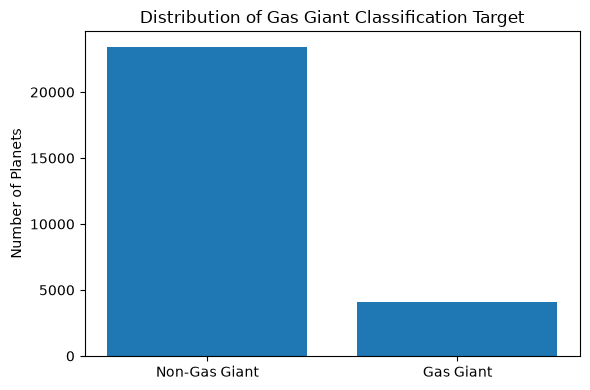

In [10]:

print(df["is_gas_giant"].value_counts())

class_counts = (
    df["is_gas_giant"]
    .value_counts()
    .sort_index()
)


class_labels = [
    "Non-Gas Giant",
    "Gas Giant"
]

plt.figure(figsize=(6, 4))

plt.bar(
    class_labels,
    class_counts.values
)

plt.ylabel("Number of Planets")
plt.title("Distribution of Gas Giant Classification Target")

plt.tight_layout()
plt.show()

In [11]:
boundary_cases = (
    df[
        df["pl_rade"].between(
            GAS_GIANT_RADIUS_THRESHOLD - 0.5,
            GAS_GIANT_RADIUS_THRESHOLD + 0.5
        )
    ]
    .sort_values("pl_rade")
)

boundary_cases[
    ["pl_name", "pl_rade", "is_gas_giant"]
].head(20)

,pl_name,pl_rade,is_gas_giant
6404,KIC 10525077 b,5.500000,0
30914,Kepler-667 b,5.500000,0
31032,Kepler-677 b,5.500000,0
30990,Kepler-673 b,5.500000,0
23921,Kepler-31 b,5.500000,0
14589,Kepler-1530 d,5.500000,0
35258,Kepler-993 b,5.500000,0
34793,Kepler-957 b,5.500000,0
22785,Kepler-279 c,5.500000,0
23925,Kepler-31 b,5.500000,0


In [12]:
threshold_audit = pd.DataFrame({
    "Radius Category": [
        f"Below or equal to {GAS_GIANT_RADIUS_THRESHOLD} R_earth",
        f"Above {GAS_GIANT_RADIUS_THRESHOLD} R_earth"
    ],
    "Expected Label": [0, 1],
    "Number of Observations": [
        (df["pl_rade"] <= GAS_GIANT_RADIUS_THRESHOLD).sum(),
        (df["pl_rade"] > GAS_GIANT_RADIUS_THRESHOLD).sum()
    ]
})

threshold_audit

,Radius Category,Expected Label,Number of Observations
0,Below or equal to 6.0 R_earth,0,23432
1,Above 6.0 R_earth,1,4108


In [13]:
assert (
    df.loc[
        df["pl_rade"] <= GAS_GIANT_RADIUS_THRESHOLD,
        "is_gas_giant"
    ] == 0
).all()

assert (
    df.loc[
        df["pl_rade"] > GAS_GIANT_RADIUS_THRESHOLD,
        "is_gas_giant"
    ] == 1
).all()

print("Target threshold audit passed.")

Target threshold audit passed.


In [14]:
class_distribution = pd.DataFrame({
    "Class": [
        "Non-Gas Giant",
        "Gas Giant"
    ],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values /
        class_counts.sum() * 100
    ).round(2)
})

class_distribution


,Class,Count,Percentage
0,Non-Gas Giant,23432,85.08
1,Gas Giant,4108,14.92


### Target Definition

A planet is classified as a gas giant when its radius exceeds 6 Earth radii.

This threshold is used as an operational classification boundary for this machine learning study. Because planetary composition cannot be determined perfectly from radius alone, this target represents a radius-based proxy for gas giant status rather than a definitive compositional classification.

In [15]:
X = df.drop(
    columns=[
        "pl_name",
        "pl_rade",
        "is_gas_giant"
    ]
)

y = df["is_gas_giant"]

print("Predictor variables:")
print(X.columns.tolist())

gas_giant_percentage = y.mean() * 100

print(
    f"Gas giants represent approximately "
    f"{gas_giant_percentage:.2f}% of the dataset."
)

Predictor variables:
['st_teff', 'st_rad', 'st_met']
Gas giants represent approximately 14.92% of the dataset.


In [30]:
assert list(X.columns) == EXPECTED_FEATURES
assert list(X_train.columns) == EXPECTED_FEATURES
assert list(X_test.columns) == EXPECTED_FEATURES
assert "pl_rade" not in X.columns
assert "is_gas_giant" not in X.columns

In [17]:
assert len(X) == len(y)
assert X.index.equals(y.index)

In [18]:
missing_summary = pd.DataFrame({
    "Missing Values": X.isna().sum(),
    "Missing (%)": (
        X.isna().mean() * 100
    ).round(2)
})

missing_features = (
    missing_summary
    .sort_values(
        "Missing (%)",
        ascending=False
    )
)

missing_features

,Missing Values,Missing (%)
st_met,8746,31.76
st_teff,1169,4.24
st_rad,444,1.61


### Why Missing Predictor Values Are Preserved

Missing values in the predictor variables are not imputed in this notebook.

Instead, they are intentionally retained until model development. In Notebook 03, imputation will be performed inside scikit-learn pipelines. During cross-validation, each imputer will be fitted only on the training portion of each fold.

This prevents information from the validation folds or held-out test set from influencing the imputation statistics.

## Train-Test Split and Leakage Prevention

The dataset is divided into training and testing sets before any model-specific preprocessing is performed. The testing set is preserved as an untouched holdout for final evaluation. In Notebook 03, missing-value imputation and feature scaling are performed inside scikit-learn pipelines. During cross-validation, these transformations are fitted independently within each training fold, preventing information from validation folds from influencing preprocessing.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)


print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

train_test_missingness = pd.DataFrame({
    "Training Missing (%)": (
        X_train.isna().mean() * 100
    ).round(2),
    "Testing Missing (%)": (
        X_test.isna().mean() * 100
    ).round(2)
})

train_test_missingness


Training observations: 22,032
Testing observations: 5,508


,Training Missing (%),Testing Missing (%)
st_teff,4.21,4.38
st_rad,1.60,1.67
st_met,31.69,32.04


In [32]:
split_configuration = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "train_size": 1 - TEST_SIZE,
    "stratified": True,
    "features": EXPECTED_FEATURES,
    "target": "is_gas_giant",
    "n_observations_before_split": len(X),
    "n_training_observations": len(X_train),
    "n_testing_observations": len(X_test)
}

with open(
    PROCESSED_DATA_PATH / "split_configuration.json",
    "w"
) as f:
    json.dump(
        split_configuration,
        f,
        indent=4
    )

print("Split configuration saved.")

Split configuration saved.


### Train-Test Missingness Comparison

The missingness proportions of the selected stellar features are compared between the training and testing partitions.

Large differences in missingness between the two partitions could indicate that the test set is systematically different from the training set. Because the split is stratified only by the target class, feature missingness is not explicitly balanced during splitting.

This comparison is therefore used as a diagnostic rather than as a basis for manually modifying the split.

In [21]:
# Check for row-level overlap between the training and testing partitions

train_index_overlap = X_train.index.intersection(X_test.index)

print(
    f"Overlapping row indices between training and testing sets: "
    f"{len(train_index_overlap)}"
)

assert len(train_index_overlap) == 0

assert len(X_train) + len(X_test) == len(X)

print("No row-level overlap detected between training and testing sets.")
print("All observations accounted for across the two partitions.")

Overlapping row indices between training and testing sets: 0
No row-level overlap detected between training and testing sets.
All observations accounted for across the two partitions.


In [34]:
rows_removed_for_missing_radius = (
    rows_before_radius_filter
    - len(df)
    - invalid_radius_count
)

print(
    f"Rows removed due to missing radius: "
    f"{rows_removed_for_missing_radius:,}"
)

print(
    f"Rows removed due to non-positive radius: "
    f"{invalid_radius_count:,}"
)

Rows removed due to missing radius: 0
Rows removed due to non-positive radius: 0


In [ ]:
# Confirm that predictor and target indices remain aligned

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

print("Predictor-target index alignment verified.")

Predictor-target index alignment verified.


In [ ]:
print("Training class distribution")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution")
print(y_test.value_counts(normalize=True).round(3))

Training class distribution
is_gas_giant
0    0.851
1    0.149
Name: proportion, dtype: float64

Testing class distribution
is_gas_giant
0    0.851
1    0.149
Name: proportion, dtype: float64


In [ ]:
split_distribution = pd.DataFrame({
    "Training (%)": y_train.value_counts(normalize=True),
    "Testing (%)": y_test.value_counts(normalize=True)
}).sort_index()

split_distribution

,Training (%),Testing (%)
is_gas_giant,,
0,0.850853,0.850763
1,0.149147,0.149237


In [31]:
class_proportion_difference = (
    y_train.mean() - y_test.mean()
)

print(
    f"Absolute difference in gas-giant proportion between "
    f"training and testing sets: "
    f"{abs(class_proportion_difference):.4f}"
)

Absolute difference in gas-giant proportion between training and testing sets: 0.0001


In [28]:
X_train.to_csv(
    PROCESSED_DATA_PATH / "X_train.csv",
    index=False
)

X_test.to_csv(
    PROCESSED_DATA_PATH / "X_test.csv",
    index=False
)

y_train.to_csv(
    PROCESSED_DATA_PATH / "y_train.csv",
    index=False
)

y_test.to_csv(
    PROCESSED_DATA_PATH / "y_test.csv",
    index=False
)

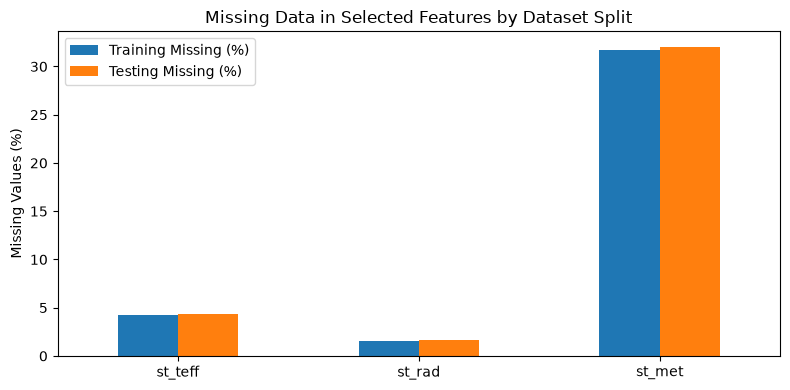

In [27]:
train_test_missingness.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.ylabel("Missing Values (%)")
plt.title("Missing Data in Selected Features by Dataset Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("Final dataset verification")

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert list(X_train.columns) == list(X_test.columns)

assert set(y_train.unique()) <= {0, 1}
assert set(y_test.unique()) <= {0, 1}

assert X_train.shape[1] == X_test.shape[1]

assert set(X_train.columns) == set(X_test.columns)

assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

assert y_train.nunique() == 2
assert y_test.nunique() == 2

print("All final dataset checks passed.")

Final dataset verification
All final dataset checks passed.


## Summary

The raw NASA Exoplanet Archive has now been transformed into a structured machine learning dataset through a reproducible preprocessing workflow.

The preprocessing workflow:

- Selected scientifically meaningful stellar features.
- Repeated `pl_name` identifiers were investigated before the train/test split. No repeated planet identifiers were found in the selected dataset. The original pandas indices were checked immediately after splitting to verify that no individual observation appeared in both partitions. The indices were then removed when the processed CSV files were exported.
- Removed observations without planetary radius because the target could not be constructed for those observations.
- Constructed a binary gas giant classification target using a radius threshold of 6 Earth radii.
- Separated the target variable from the stellar predictors.
- Split the data into stratified training and testing sets.
- Preserved missing values so that imputation can be learned inside model pipelines without data leakage during cross-validation.

The resulting training and testing datasets are now ready for model development.

In the next notebook, preprocessing operations such as missing-value imputation and feature scaling will be performed inside scikit-learn pipelines. This ensures that each cross-validation fold learns preprocessing parameters only from its own training subset.